# Linear Regression 1
The `LinearRegression` estimator is usd to find equation of line:
$$
y = a_0 + a_1 x_1 + a_2 x_2 + \cdots
$$
where there are multiple $x$ values.
Geometrically, this is akin to fitting a plane to points in three dimensions, or fitting a hyperplane to points in higher dimensions.
Here $x_1$ , $x_2$, etc are features

We need to find relation between independent features PTT, Pulse_Rate, and the target variable Systolic_BP
- PTT: pulse transit time 

Here we are trying to find equation of line, 
$$
y = a_0 + a_1 x_1 + a_2 x_2 
$$

that can describe relation between $x_1$ (PTT), $x_2$ (Pulse Rate) and y (SBP). $a_0$ is the intercept and $a_1$ is the $x_1$-coefficient, $a_2$ is the $x_2$-coefficient..

In [9]:
# # Lets generate a synthetic data
# import numpy as np
# import pandas as pd

# np.random.seed(42)
# n = 100
# pulse_rate = np.random.randint(60, 85, size=n)
# ptt = np.random.randint(190, 260, size=n)
# noise = np.random.normal(0, 0.7, size=n)

# sbp = 180 - 0.2 * ptt + 0.5 * pulse_rate + noise

# df = pd.DataFrame({
#     'Pulse_Rate': pulse_rate,
#     'PTT': ptt,
#     'Systolic_BP': sbp.round(1)
# })

# print(df.head())
# df.to_csv('biomedical_sbl.csv', index=False)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Problem formulation

# 2. Data collection
Lets load the dataset

In [2]:
# df = pd.read_csv('biomedical_sbl.csv')
# df = pd.read_csv('/content/sample_data/biomedical_sbl.csv') # use this when uploading the CSV file to colab

# Use following when running directly from github. The raw URL is obtained by clicking on the raw button.
# df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/tut_ml/refs/heads/master/tut_linear_regression/biomedical_sbl.csv')

df = pd.read_csv('data_biomedical_sbl.csv')
print(df)

    Pulse_Rate  PTT  Systolic_BP
0           66  198        174.3
1           79  190        181.2
2           74  197        177.3
3           70  252        164.9
4           67  200        174.9
..         ...  ...          ...
95          72  206        174.7
96          68  227        167.5
97          74  213        175.8
98          72  258        163.6
99          60  259        159.0

[100 rows x 3 columns]


# 3. Fix Data Types + Data cleaning + Data labelling


In [13]:
# Finding and Handling Duplicate Records
duplicates = df.duplicated()
print("\nDuplicate Records:\n", df[duplicates])

# observ: no duplicates


Duplicate Records:
 Empty DataFrame
Columns: [Pulse_Rate, PTT, Systolic_BP]
Index: []


# 4. Exploratory Data Analysis (EDA)
You want to get to know your data first - this includes visualizing features, exploring their relationships and making hypotheses based on your observations. The dataset is a CSV (comma-separated values) file, which contains the data that relates systolic BP with PTT and Pulse rate

In [3]:
print(df.head(5)) # prints the first 5 records

   Pulse_Rate  PTT  Systolic_BP
0          66  198        174.3
1          79  190        181.2
2          74  197        177.3
3          70  252        164.9
4          67  200        174.9


In [4]:
print(df.tail(4)) # prints the last 4 records

    Pulse_Rate  PTT  Systolic_BP
96          68  227        167.5
97          74  213        175.8
98          72  258        163.6
99          60  259        159.0


In [5]:
print(df.shape) # display (rows,columns)

(100, 3)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pulse_Rate   100 non-null    int64  
 1   PTT          100 non-null    int64  
 2   Systolic_BP  100 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 2.5 KB
None


### observation
- There are total of 100 entries
- Pulse_rate, PTT has 100 non-null entries
- Systolic_BP has 100 non-null entries 

In [7]:
print(df.describe())

       Pulse_Rate       PTT  Systolic_BP
count  100.000000  100.0000   100.000000
mean    72.570000  223.3100   171.584000
std      7.139667   21.6369     5.919813
min     60.000000  190.0000   159.000000
25%     67.000000  202.7500   167.000000
50%     73.000000  223.5000   172.200000
75%     79.000000  242.2500   175.650000
max     84.000000  259.0000   183.600000


### Lets visualize
we're asking for the relationship between Pulse_rate, PTT and Systolic_BP. So, what's the relationship between these variables? A great way to explore relationships between variables is through Scatter plots. We'll plot the hours on the X-axis and scores on the Y-axis, and for each pair, a marker will be positioned based on their values:

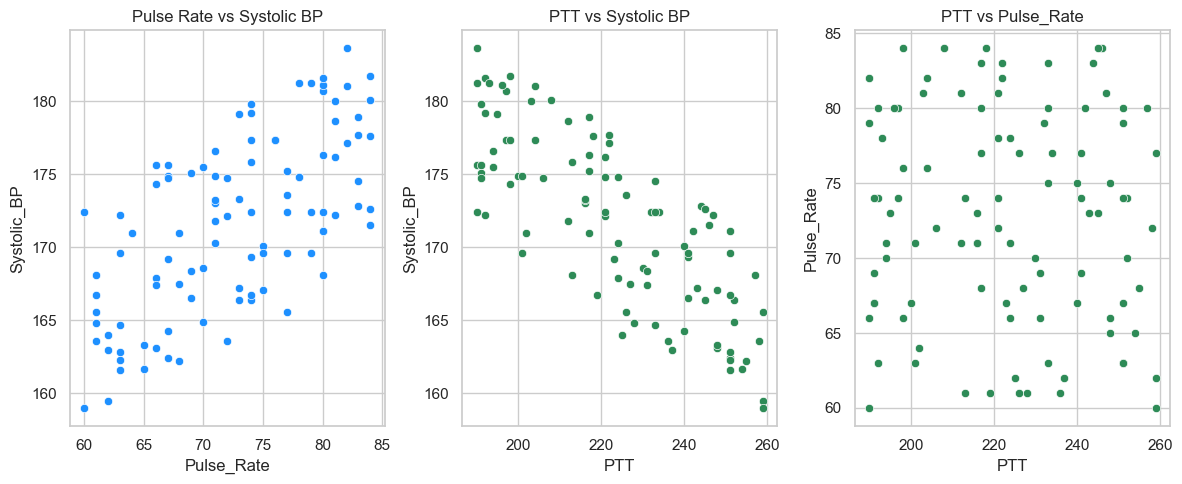

In [8]:
# Lets plot relation between Pulse_rate and PTT

# Or use seaborn for better quality
sns.set(style='whitegrid', palette='muted') # Set Seaborn theme

# Create scatter plots
plt.figure(figsize=(12, 5))

# Scatter plot: Pulse Rate vs Systolic BP
plt.subplot(1, 3, 1)
sns.scatterplot(x='Pulse_Rate', y='Systolic_BP', data=df, color='dodgerblue')
plt.title('Pulse Rate vs Systolic BP')

# Scatter plot: PTT vs Systolic BP
plt.subplot(1, 3, 2)
sns.scatterplot(x='PTT', y='Systolic_BP', data=df, color='seagreen')
plt.title('PTT vs Systolic BP')

# Scatter plot: PTT vs pulse_rate
plt.subplot(1, 3, 3)
sns.scatterplot(x='PTT', y='Pulse_Rate', data=df, color='seagreen')
plt.title('PTT vs Pulse_Rate')

plt.tight_layout()
plt.show()

# Observation: Pulse rate and Systolic_BP has positive linear relationship
# PTT and Systolic_BP has negative linear relationship
# Pulse rate and PTT has no relationship

### Box plot

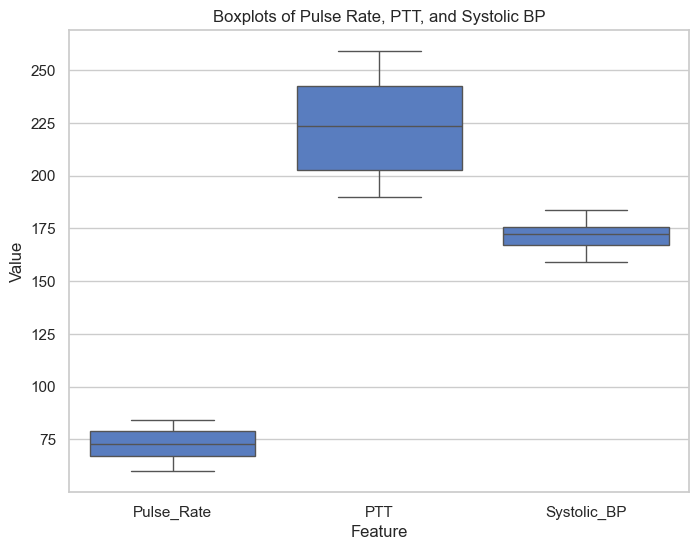

In [9]:
# Melt the DataFrame to long format for seaborn: NOT A GOOD IDEA TO PLOT ALL IN SAME FIG
# STEP1
df_melted = df[['Pulse_Rate', 'PTT', 'Systolic_BP']].melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Feature', y='Value', data=df_melted)
plt.title('Boxplots of Pulse Rate, PTT, and Systolic BP')
plt.show()

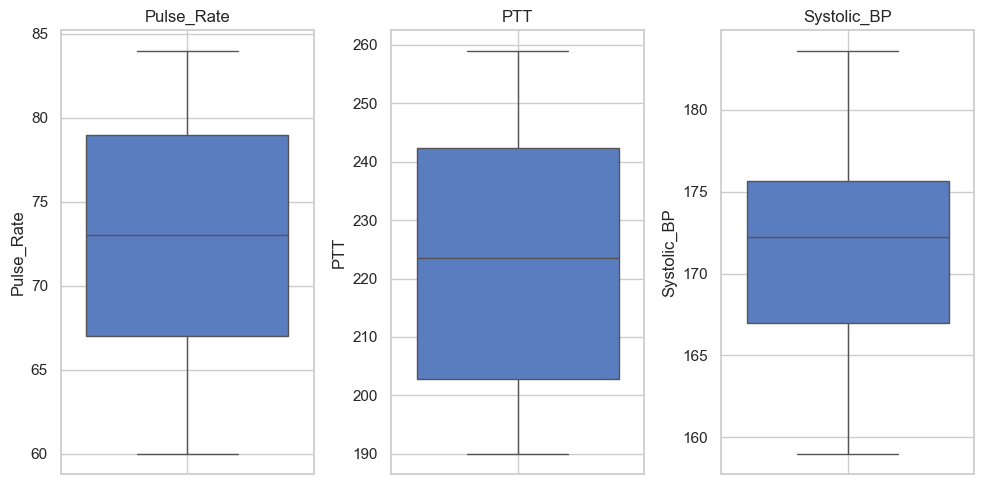

In [10]:
# STEP2: LETS plot above in 3 seperate fig
# Create a figure with 2 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Boxplot1
sns.boxplot(y=df['Pulse_Rate'], ax=axes[0])
axes[0].set_title('Pulse_Rate')
axes[0].grid(True)

# Boxplot2
sns.boxplot(y=df['PTT'], ax=axes[1])
axes[1].set_title('PTT')
axes[1].grid(True)

# Boxplot3
sns.boxplot(y=df['Systolic_BP'], ax=axes[2])
axes[2].set_title('Systolic_BP')
axes[2].grid(True)


plt.tight_layout()
plt.show()


In [11]:
# Lets find the value of outlier in Pulse_Rate:
# Step 1: Calculate Q1, Q3 and IQR

col = 'Pulse_Rate'
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q2:{Q2}")
print(f"Q3:{Q3}")
print(f"IQR:{IQR}")

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

# Step 4: Print the outliers
print(f"Outliers in '{col}' column:")
print(outliers) # print the whole rows
print(outliers[col].values) # print the just the col values

Q1:67.0
Q2:73.0
Q3:79.0
IQR:12.0
Outliers in 'Pulse_Rate' column:
Empty DataFrame
Columns: [Pulse_Rate, PTT, Systolic_BP]
Index: []
[]


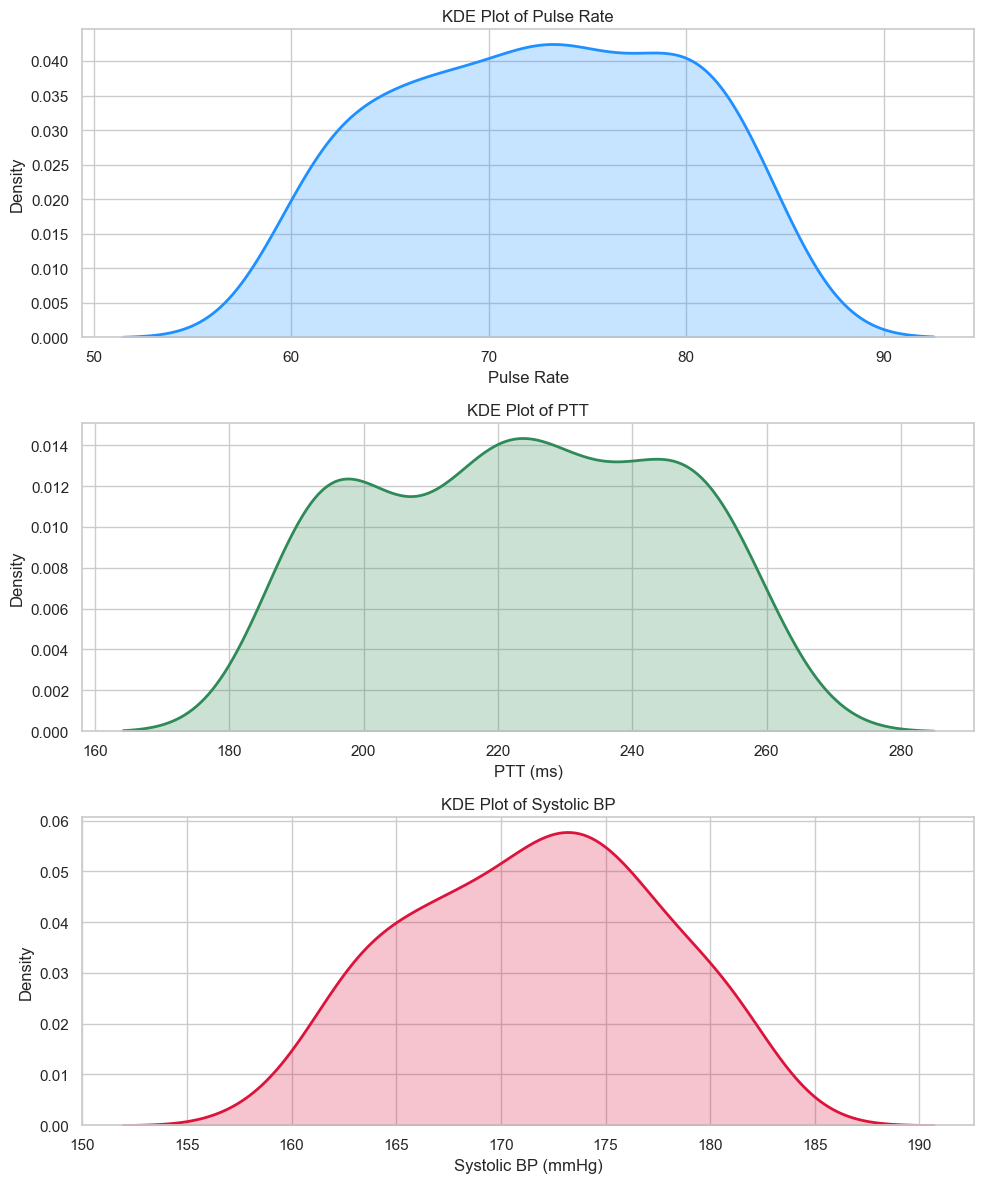

In [12]:
# lets plot KDE for all columns
# Set Seaborn style
sns.set(style='whitegrid')

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

# KDE for Pulse Rate
sns.kdeplot(df['Pulse_Rate'], fill=True, linewidth=2, ax=axes[0], color='dodgerblue')
axes[0].set_title('KDE Plot of Pulse Rate')
axes[0].set_xlabel('Pulse Rate')
axes[0].set_ylabel('Density')

# KDE for PTT
sns.kdeplot(df['PTT'], fill=True, linewidth=2, ax=axes[1], color='seagreen')
axes[1].set_title('KDE Plot of PTT')
axes[1].set_xlabel('PTT (ms)')
axes[1].set_ylabel('Density')

# KDE for Systolic BP
sns.kdeplot(df['Systolic_BP'], fill=True, linewidth=2, ax=axes[2], color='crimson')
axes[2].set_title('KDE Plot of Systolic BP')
axes[2].set_xlabel('Systolic BP (mmHg)')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

# 6. Label encoding + Data split: train + test


In [14]:

# split dataset into train and test set. We would use training data to train the model

X = df[['Pulse_Rate','PTT']] # These are 2 indep variable. This is the feature that would predict the y
y = df['Systolic_BP']        # this is the response variable

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lets see how many records are in training and testing dataset
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")


X_train shape:(80, 2)
X_test shape:(20, 2)


# 5. Data Preprocessing and Feature Engineering

## Lets check and deal with missing values

In [ ]:
# check missing values
missing_values = X_train.isnull().sum()
print(missing_values)

Pulse_Rate     0
PTT            0
Systolic_BP    0
dtype: int64


### Good. No missing values

# Any correlation ?
we see that there's no correlation between the PTT and Pulse_rate variables. How correlated are they? Anything above 0.8 is considered to be a strong positive correlation.
**Generally you do not include response variable here**

In [17]:
#STEP1: compute correlation between features in feature space. We do not use target variable.
corr = X_train.corr()
print(corr) 

            Pulse_Rate       PTT
Pulse_Rate    1.000000 -0.121907
PTT          -0.121907  1.000000


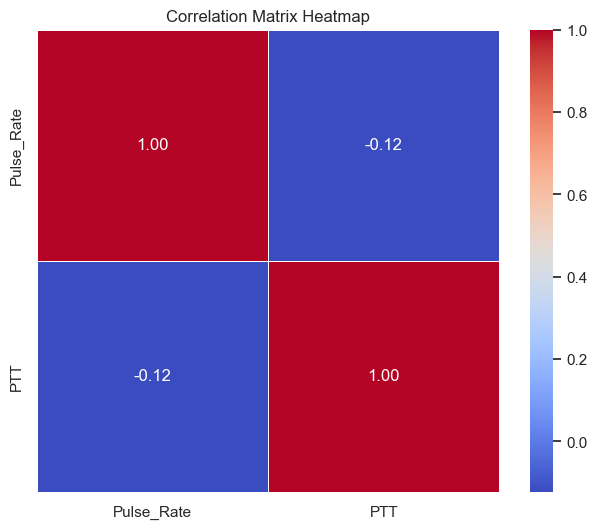

In [18]:
# STEP2
# Set seaborn style
sns.set(style='whitegrid')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

plt.title("Correlation Matrix Heatmap")
plt.show()

# observation: No correlation  between Pulse_rate and PTT

## observation

1. Pulse_Rate vs PTT 
- Interpretation: Very weak negative correlation.
- Meaning: As Pulse_Rate increases, PTT slightly tends to decrease, but the relationship is extremely weak and likely insignificant.


# 7. Modelling and Training

In [22]:
# Modelling means picking up the right model: Here I choose LinearRegression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Now I train the  model
model.fit(X_train, y_train)

LinearRegression()

In [24]:
# Lets make a prediction on SBP for person whose  Pulse_rate=66 and PTT=198 
new_data = pd.DataFrame([[66, 198],], columns=X_train.columns)

SBP = model.predict(new_data)
print("The SBP is", SBP)

The SBP is [173.4075602]


# Analyze:
## The y intercept
To find the equation of line, 
$$
y = a_0 + a_1 x_1 + a_2 x_2
$$
we need to find  $a_0$ , $a_1$ and $a_2$. We can get that from the above model.

In [25]:
# Step1: Now lets extract a0, a1, a2:

a0 = model.intercept_ # intercept
a1 = model.coef_[0] # # x1-coefficient or slope
a2 = model.coef_[1] # # x2-coefficient or slope

print(f"The intercept a0: {a0}")
print(f"The x1-coeff a1: {a1}")
print(f"The x2-coeff a2: {a2}")

The intercept a0: 180.1958663738138
The x1-coeff a1: 0.502792998201693
The x2-coeff a2: -0.20188204069327462


In [26]:
# Step2: Lets round them up
a0 = round(a0,4) # intercept
a1 = round(a1,4) # # x1-coefficient or slope
a2 = round(a2,4) # # x2-coefficient or slope

print(f"The intercept: {a0}")
print(f"The x1-coeff: {a1}")
print(f"The x2-coeff: {a2}")

The intercept: 180.1959
The x1-coeff: 0.5028
The x2-coeff: -0.2019


This can quite literally be plugged in into our formula from before:
$$
y = 180.1959 + 0.5028 ∗ x_1 -0.2019 * x_2
$$

**SBP = 180.1959 + 0.5028 ∗ Pulse_rate -0.2019 * PTT**


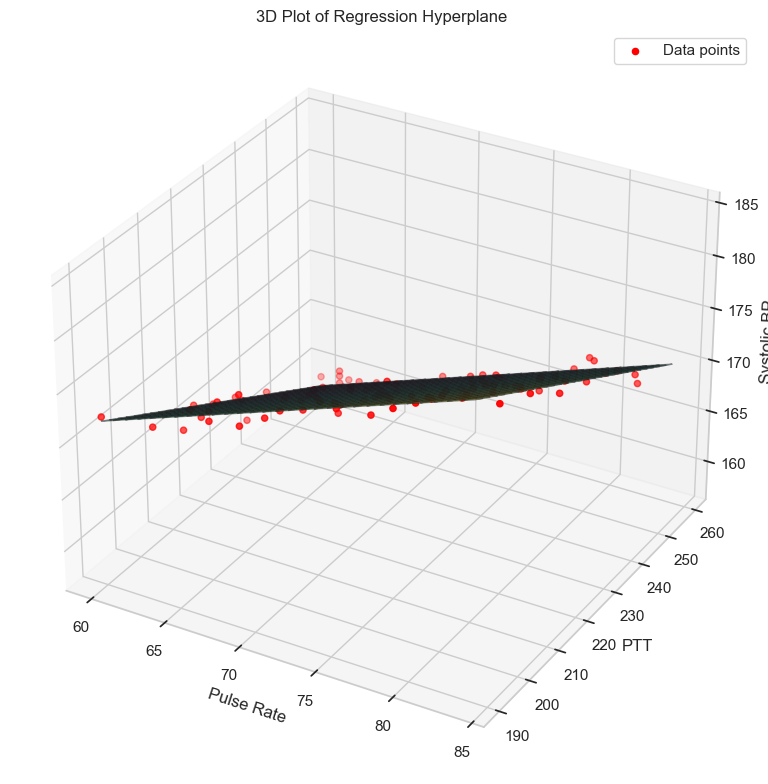

In [27]:
# lets plot this hyperplane

from mpl_toolkits.mplot3d import Axes3D

# Assume df already contains Pulse_Rate, PTT, and Systolic_BP

# Create meshgrid for Pulse_Rate and PTT
pulse_range = np.linspace(df['Pulse_Rate'].min(), df['Pulse_Rate'].max(), 30)
ptt_range = np.linspace(df['PTT'].min(), df['PTT'].max(), 30)
pulse_grid, ptt_grid = np.meshgrid(pulse_range, ptt_range)

# Compute SBP values from the regression equation
sbp_grid = a0 + a1 * pulse_grid + a2 * ptt_grid

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original data points
ax.scatter(df['Pulse_Rate'], df['PTT'], df['Systolic_BP'], color='red', label='Data points')

# Plot the regression hyperplane
ax.plot_surface(pulse_grid, ptt_grid, sbp_grid, alpha=0.5, cmap='viridis', edgecolor='k')

# Labels and title
ax.set_xlabel('Pulse Rate')
ax.set_ylabel('PTT')
ax.set_zlabel('Systolic BP')
ax.set_title('3D Plot of Regression Hyperplane')

plt.legend()
plt.tight_layout()
plt.show()

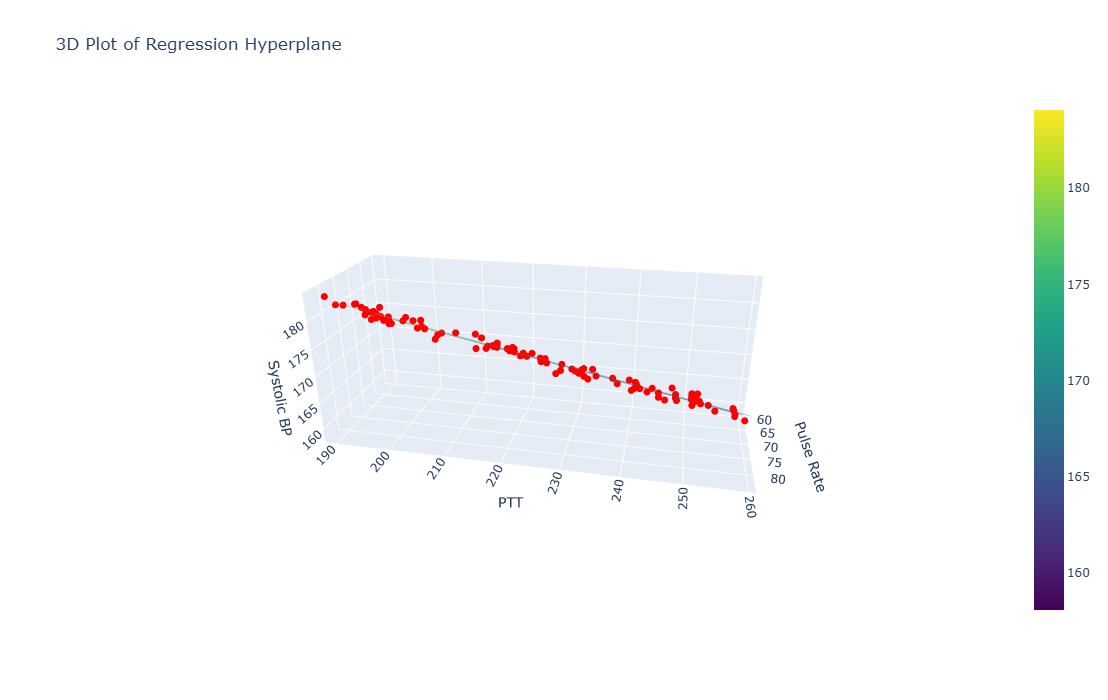

In [38]:
# Lets replot above using plotly: Mind that the file size would increase with use of plotly.

import plotly.graph_objects as go

# Assume df is already defined with Pulse_Rate, PTT, Systolic_BP
# Create meshgrid
pulse_range = np.linspace(df['Pulse_Rate'].min(), df['Pulse_Rate'].max(), 30)
ptt_range = np.linspace(df['PTT'].min(), df['PTT'].max(), 30)
pulse_grid, ptt_grid = np.meshgrid(pulse_range, ptt_range)

# Compute predicted SBP values using regression equation
sbp_grid = a0 + a1 * pulse_grid + a2 * ptt_grid

# Create the surface trace (regression plane)
surface = go.Surface(
    x=pulse_grid,
    y=ptt_grid,
    z=sbp_grid,
    colorscale='Viridis',
    opacity=0.5,
    name='Regression Plane'
)

# Create the scatter trace (original data points)
scatter = go.Scatter3d(
    x=df['Pulse_Rate'],
    y=df['PTT'],
    z=df['Systolic_BP'],
    mode='markers',
    marker=dict(size=4, color='red'),
    name='Data Points'
)

# Combine and plot
fig = go.Figure(data=[surface, scatter])
fig.update_layout(
    title='3D Plot of Regression Hyperplane',
    scene=dict(
        xaxis_title='Pulse Rate',
        yaxis_title='PTT',
        zaxis_title='Systolic BP'
    ),
    width=800,
    height=700
)

fig.show()


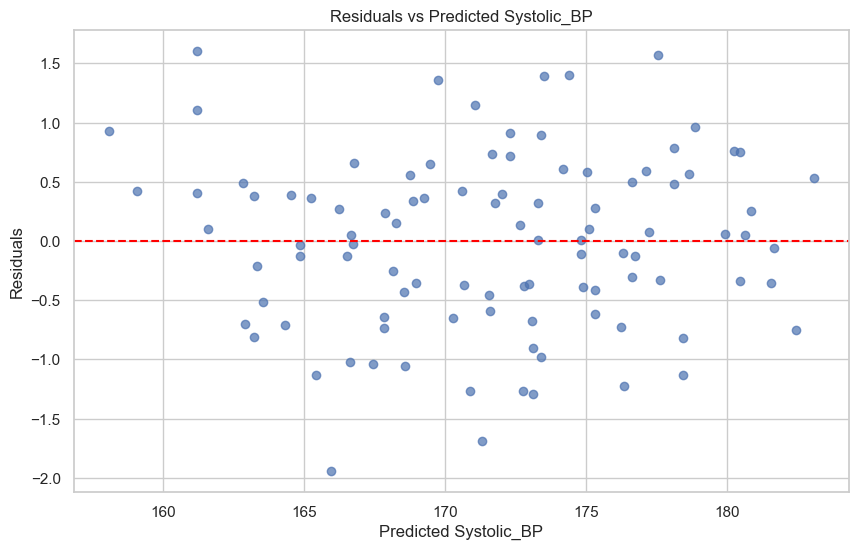

In [28]:
# Lets plot residuals

# Regression coefficients
intercept = a0
coef_pulse = a1
coef_ptt = a2

# Predicted Systolic_BP
df['Predicted_SBP'] = intercept + coef_pulse * df['Pulse_Rate'] + coef_ptt * df['PTT']

# Residuals = Actual - Predicted
df['Residuals'] = df['Systolic_BP'] - df['Predicted_SBP']

# Plot residuals vs predicted SBP
plt.figure(figsize=(10, 6))
plt.scatter(df['Predicted_SBP'], df['Residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Systolic_BP')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Systolic_BP')
plt.grid(True)
plt.show()

In [ ]:
# lets print the residuals to see the difference between actual,predicted values.
print(df)

## observation:
This will help you visually assess whether your residuals have a random pattern (good) or a trend (which could suggest model inadequacy).
Ideally U want your data points to be on red line, which has residual=0

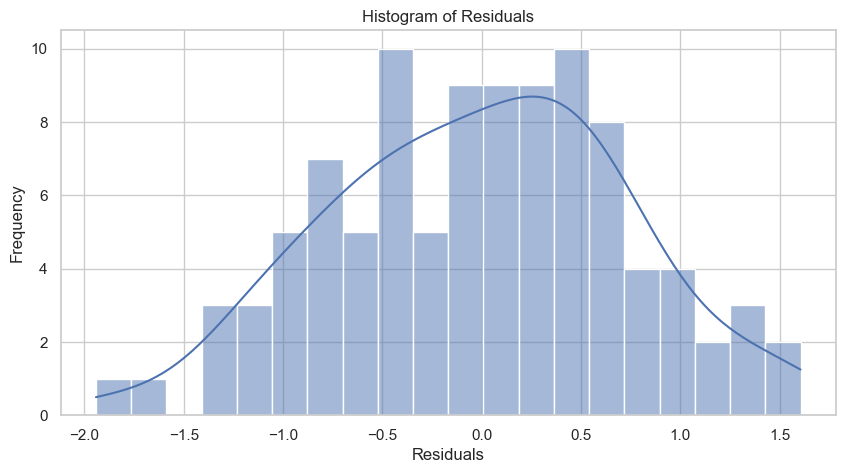

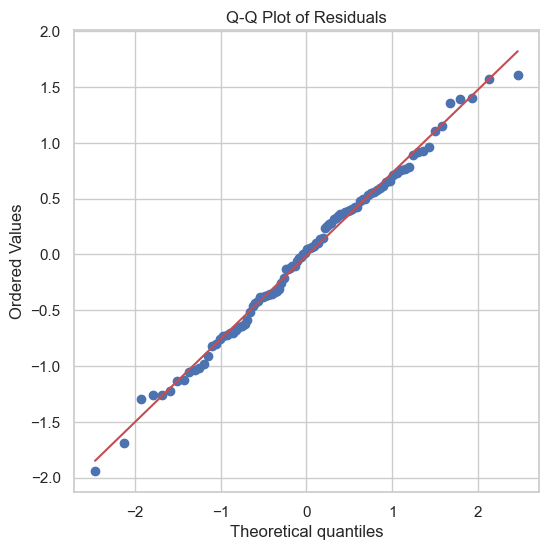

In [29]:
# Lets check for normality of residuals using Histogram or Q-Q plots
# Histogram: Should resemble a bell curve if residuals are normally distributed.
# Q-Q plot: Points should lie roughly on the diagonal line. Major deviations suggest non-normality.

import scipy.stats as stats

# Histogram of residuals
plt.figure(figsize=(10, 5))
sns.histplot(df['Residuals'], kde=True, bins=20)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Q-Q plot of residuals
plt.figure(figsize=(6, 6))
stats.probplot(df['Residuals'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()


## Lets calculate SBP manually and also using the predict method

In [30]:
# Lets write a simple code to calculate score based on eqn: SBP = a0 + a1 * pulse_rate + a2 * PTT

pulse_rate = 66
ptt        = 198

sbp = a0 + a1 * pulse_rate + a2 * ptt
print(sbp)

173.40449999999998


In [31]:
# Lets make a prediction on SBP for person whose  Pulse_rate=66 and PTT=198 
new_data = pd.DataFrame([[66, 198],], columns=X_train.columns)

SBP = model.predict(new_data)
print("The SBP is", SBP)

The SBP is [173.4075602]


### Both are same
So I wanted to show that this predicted value can also be obtained via the line intercept and slope value

# Predict values for larger dataset

In [33]:
X_values = [
    # pulse_rate, PTT
    [66, 198],  # patient1
    [70, 194],  # patient2
    [61,231],   # patient3
]

new_data = pd.DataFrame(X_values, columns=X_train.columns)

sbp = model.predict(new_data)
print(sbp)

[173.4075602  176.22626035 164.23148786]


# 8. Model Performance Evaluation

In [34]:
# STEP1: Lets make prediction on test data set
y_pred = model.predict(X_test)
print(y_pred)

[167.84241935 173.38079075 176.30616823 162.90586987 176.6109034
 178.42019335 161.59937292 167.83859515 168.95850689 173.4075602
 169.74691402 177.22419794 171.05723518 166.52827399 166.6234787
 173.50658911 164.83713399 176.32911348 180.85042625 168.25383185]


In [35]:
# Now lets the see absolute difference between the actual and prediction and also the percentage difference.

df_preds = pd.DataFrame({
    'actual_value': y_test.squeeze(),
    'predicted_value': y_pred.squeeze()})

df_preds['difference'] = (df_preds['actual_value'] - df_preds['predicted_value']).abs()

# Add the percentage difference column
df_preds['percentage_difference'] = (
    df_preds['difference'] / df_preds['actual_value']
) * 100

print(df_preds)

    actual_value  predicted_value  difference  percentage_difference
83         167.2       167.842419    0.642419               0.384222
53         172.4       173.380791    0.980791               0.568904
70         176.2       176.306168    0.106168               0.060254
45         162.2       162.905870    0.705870               0.435185
44         176.3       176.610903    0.310903               0.176349
39         177.6       178.420193    0.820193               0.461821
22         161.7       161.599373    0.100627               0.062231
80         167.1       167.838595    0.738595               0.442008
10         168.6       168.958507    0.358507               0.212638
0          174.3       173.407560    0.892440               0.512014
18         171.1       169.746914    1.353086               0.790816
30         177.3       177.224198    0.075802               0.042754
73         172.2       171.057235    1.142765               0.663626
33         166.4       166.528274 

##### Not much difference between actual and predicted score

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Compute R-squared (R²) value
r2 = r2_score(y_test, y_pred)

# Compute percentage-based errors
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error
relative_mae = (mae / np.mean(y_test)) * 100  # Relative MAE
relative_rmse = (rmse / np.mean(y_test)) * 100  # Relative RMSE
nrmse = (rmse / (y_test.max() - y_test.min())) * 100  # Normalized RMSE

# Print all results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.4f}')  # closer to 1 is good
print("########################")

print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'Relative MAE: {relative_mae:.2f}%')
print(f'Relative RMSE: {relative_rmse:.2f}%')
print(f'Normalized RMSE (NRMSE): {nrmse:.2f}%')


Mean Absolute Error (MAE): 0.62
Mean Squared Error (MSE): 0.59
Root Mean Squared Error (RMSE): 0.77
R-squared (R²): 0.9796
########################
Mean Absolute Percentage Error (MAPE): 0.36%
Relative MAE: 0.36%
Relative RMSE: 0.45%
Normalized RMSE (NRMSE): 3.97%


### R-square value looking awesome

# 9. Hyperparameter tuning
No hyper parameters to tune.

# 10. Final Evaluation

# Save the model
- After saving the model, you can deploy the model on your server or any app that you use.

In [37]:
# save the model
import joblib

joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

# Load the model later

In [38]:
# load the model
import joblib

loaded_model = joblib.load('linear_regression_model.pkl')

In [39]:
# make prediction
X_values = [
    # pulse_rate, PTT
    [66, 198],  # patient1
    [70, 194],  # patient2
    [61,231],   # patient3
]

new_data = pd.DataFrame(X_values, columns=X_train.columns)

sbp = loaded_model.predict(new_data)
print(sbp)

[173.4075602  176.22626035 164.23148786]
